In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

print(jax.devices())

from src_renyi import (
    ARNN_Z2, RBM_Z2,
    FreeRenyiEnergyObservable,
    free_energy_minimize_SR_SGD,
    free_energy_minimize_scipy,
    renyi_entropy_maximize_SR_SGD,
    renyi2_entropy_and_grad_sampled,
    renyi2_entropy_and_grad_sampled2,
    renyi2_entropy_and_grad_lambda_integral,
    renyi2_entropy_and_grad_cv
)

[CudaDevice(id=0)]


In [2]:
# Hilbert space
from netket.hilbert import Spin
N = 10
N_ancilla = 10
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

Step    0 | F=-35.357408 | t=0.366s
Step   20 | F=-52.145048 | t=0.110s
Step   40 | F=-54.562453 | t=0.113s
Step   60 | F=-61.774761 | t=0.113s
Step   80 | F=-61.244581 | t=0.124s
Step  100 | F=-62.253692 | t=0.120s
Step  120 | F=-62.681840 | t=0.114s
Step  140 | F=-60.406163 | t=0.120s
Step  160 | F=-64.490857 | t=0.122s
Step  180 | F=-63.901016 | t=0.118s
Step  200 | F=-64.457525 | t=0.124s
Step  220 | F=-62.997779 | t=0.120s
Step  240 | F=-61.850297 | t=0.132s
Step  260 | F=-62.944661 | t=0.129s
Step  280 | F=-62.734849 | t=0.140s


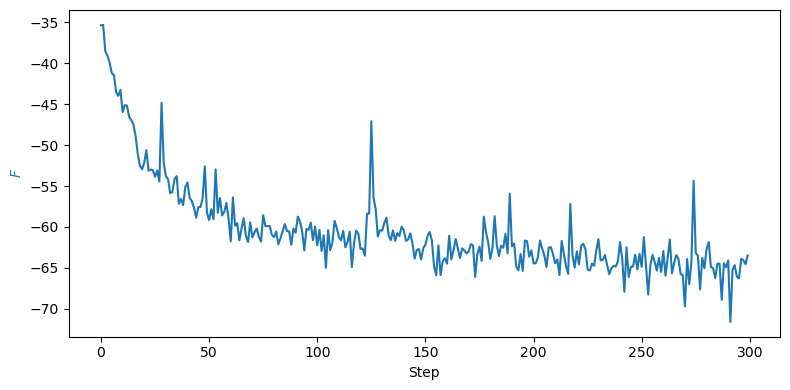

Best solution: S₂=6.191554, E=-3.691407, F=-65.606944


In [7]:
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*1)
T = 10

n_steps = 300
lr = optax.linear_schedule(0.005, 0.0001, n_steps)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)
_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

In [11]:
arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960/2)
lr = optax.linear_schedule(0.1, 0.05, n_steps)
_,_,_ = renyi_entropy_maximize_SR_SGD(vstate, partition, 300, 50, learning_rate=lr, diag_shift=diag_shift, timing=True)

Step    0 | S₂=2.413794 | t=0.406s
Step   50 | S₂=5.952082 | t=0.211s


KeyboardInterrupt: 

In [5]:
from itertools import product
def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def renyi2_grad_exact(vstate, subsystem_sites, isFullSum=False):
    """
    Calcula el gradiente exacto de la entropía de Rényi-2 usando
    diferenciación automática sobre la función que calcula S₂ exactamente.
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
        grad_S2: gradiente exacto (misma estructura que vstate.parameters)
    """
    
    # Definir una función que solo depende de los parámetros
    def S2_func(params):
        # Crear un estado temporal con los parámetros dados
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hi_extended, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(sampler=vstate.sampler,model=vstate.model,n_samples=vstate.n_samples,)
        vstate_tmp.parameters = params
        S2, _ = renyi2_entropy_exact(vstate_tmp, subsystem_sites)
        return S2
    
    # Usar value_and_grad de JAX para obtener S₂ y su gradiente
    S2, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2, S2_grad

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

In [10]:
val1, grad1 = renyi2_grad_exact(vstate, partition)
n1=jnp.linalg.norm(jax.flatten_util.ravel_pytree(grad1)[0])
g1, _ = jax.flatten_util.ravel_pytree(grad1)
print(f"Exact ___ S2: {val1:.3f}, {n1:.3f}")
for i in range (5):
    val2, grad2 = renyi2_entropy_and_grad_cv(vstate, partition, vstate.n_samples)
    n2=jnp.linalg.norm(jax.flatten_util.ravel_pytree(grad2)[0])

    val3, grad3 = renyi2_entropy_and_grad_lambda_integral(vstate, partition, vstate.n_samples, 30)
    n3=jnp.linalg.norm(jax.flatten_util.ravel_pytree(grad3)[0])

    
    g2, _ = jax.flatten_util.ravel_pytree(grad2)
    g3, _ = jax.flatten_util.ravel_pytree(grad3)
    cos_angle = jnp.dot(g1, g2) / (
        jnp.linalg.norm(g1) * jnp.linalg.norm(g2)
    )
    cos_angle2 = jnp.dot(g1, g3) / (
        jnp.linalg.norm(g1) * jnp.linalg.norm(g3)
    )

    # print(f"S2: {val2:.3f}, {val3:.3f}")
    print(f"Grad: {n2:.3f}, {n3:.3f}")
    print("cos(angle) =", cos_angle)
    print("cos(angle) =", cos_angle2)

Exact ___ S2: 6.049, 0.544
Grad: 1.843, 1.996
cos(angle) = 0.056037450640272726
cos(angle) = 0.30537100169243336
Grad: 2.077, 2.158
cos(angle) = 0.34367998111155856
cos(angle) = 0.17497815263687821
Grad: 2.207, 2.000
cos(angle) = 0.3205199111761818
cos(angle) = 0.2048134526020164
Grad: 2.597, 2.297
cos(angle) = 0.1422441832464555
cos(angle) = 0.3678651450627159
Grad: 1.994, 2.439
cos(angle) = 0.29720710984120446
cos(angle) = -0.03867544190840211


In [8]:
def diagnose_sampling(vstate, subsystem_sites, n_samples, n_lambda=10, key=0):
    """
    Diagnostica la calidad del muestreo para entropías altas.
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    all_sites = jnp.arange(vstate.hilbert.size)
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    # Muestrear
    all_samples = vstate.sample(n_samples=2 * n_samples).reshape(-1, vstate.hilbert.size)
    rng = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(rng, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:]
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    # Calcular R
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    log_R = jnp.real(log_s1 + log_s2 - log_o1 - log_o2)
    R = jnp.exp(log_R)
    R_mean = jnp.mean(R)
    S2 = -jnp.log(R_mean)
    
    # Calcular ESS para diferentes λ
    lambda_grid = jnp.linspace(0.0, 1.0, n_lambda)
    
    print(f"S₂ estimada: {S2:.4f}")
    print(f"⟨R⟩ = {R_mean:.6f}")
    print(f"n_samples = {n_samples}")
    print(f"ESS teórico para λ=1: {n_samples * R_mean:.1f}")
    print()
    
    for lam in lambda_grid:
        log_weights = lam * log_R
        log_weights -= jax.nn.logsumexp(log_weights)
        weights = jnp.exp(log_weights)
        ess = 1.0 / jnp.sum(weights**2)
        print(f"λ={lam:.2f}: ESS = {ess:.1f} ({ess/n_samples*100:.1f}%)")
    
    # Mostrar distribución de R
    percentiles = jnp.percentile(R, jnp.array([50, 90, 95, 99, 99.9]))
    print(f"\nPercentiles de R:")
    print(f"  mediana: {percentiles[0]:.6f}")
    print(f"  90%: {percentiles[1]:.6f}")
    print(f"  95%: {percentiles[2]:.6f}")
    print(f"  99%: {percentiles[3]:.6f}")
    print(f"  99.9%: {percentiles[4]:.6f}")
    print(f"  máximo: {jnp.max(R):.6f}")
    
    return S2, R

diagnose_sampling(vstate, partition, vstate.n_samples, 30)

S₂ estimada: 6.0844
⟨R⟩ = 0.002278
n_samples = 40960
ESS teórico para λ=1: 93.3

λ=0.00: ESS = 40960.0 (100.0%)
λ=0.03: ESS = 29283.9 (71.5%)
λ=0.07: ESS = 15138.1 (37.0%)
λ=0.10: ESS = 7364.8 (18.0%)
λ=0.14: ESS = 3702.1 (9.0%)
λ=0.17: ESS = 1996.1 (4.9%)
λ=0.21: ESS = 1171.4 (2.9%)
λ=0.24: ESS = 749.0 (1.8%)
λ=0.28: ESS = 518.1 (1.3%)
λ=0.31: ESS = 383.5 (0.9%)
λ=0.34: ESS = 300.4 (0.7%)
λ=0.38: ESS = 246.4 (0.6%)
λ=0.41: ESS = 209.6 (0.5%)
λ=0.45: ESS = 183.7 (0.4%)
λ=0.48: ESS = 164.8 (0.4%)
λ=0.52: ESS = 150.6 (0.4%)
λ=0.55: ESS = 139.8 (0.3%)
λ=0.59: ESS = 131.3 (0.3%)
λ=0.62: ESS = 124.5 (0.3%)
λ=0.66: ESS = 119.0 (0.3%)
λ=0.69: ESS = 114.5 (0.3%)
λ=0.72: ESS = 110.7 (0.3%)
λ=0.76: ESS = 107.6 (0.3%)
λ=0.79: ESS = 104.9 (0.3%)
λ=0.83: ESS = 102.6 (0.3%)
λ=0.86: ESS = 100.7 (0.2%)
λ=0.90: ESS = 98.9 (0.2%)
λ=0.93: ESS = 97.4 (0.2%)
λ=0.97: ESS = 96.1 (0.2%)
λ=1.00: ESS = 94.9 (0.2%)

Percentiles de R:
  mediana: 0.000000
  90%: 0.000000
  95%: 0.000000
  99%: 0.000390
  99.9%: 1.

(Array(6.08436543, dtype=float64),
 Array([6.31788874e-23, 5.04163045e-21, 2.32772525e-21, ...,
        1.33931924e-29, 2.76206520e-13, 4.62348192e-19], dtype=float64))

In [9]:
for i in range (5):
    val2, grad2 = renyi2_entropy_and_grad_sampled(vstate, partition, vstate.n_samples)
    n2=jnp.linalg.norm(jax.flatten_util.ravel_pytree(grad2)[0])

    val3, grad3 = renyi2_entropy_and_grad_cv(vstate, partition, vstate.n_samples, diagnostics=True)
    n3=jnp.linalg.norm(jax.flatten_util.ravel_pytree(grad3)[0])

    print(f"S2: {val2:.3f}, {val3:.3f}")
    print(f"Grad: {n2:.3f}, {n3:.3f}")

── Diagnostics ──────────────────────────
  mean(R)      = 2.415e-03
  std(R)       = 5.132e-02
  max(R)       = 4.281e+00
  mean(log_R)  = -45.226
  std(log_R)   = 19.853
  corr(R,logp) = 0.004  → CV reducción ≈ 100.0% NO, 0.0% SÍ
  corr(R,logR) = 0.107  → CV reducción ≈ 1.1% SÍ
─────────────────────────────────────────
S2: 6.091, 6.026
Grad: 1.930, 2.209
── Diagnostics ──────────────────────────
  mean(R)      = 2.285e-03
  std(R)       = 5.271e-02
  max(R)       = 5.611e+00
  mean(log_R)  = -45.483
  std(log_R)   = 19.753
  corr(R,logp) = -0.004  → CV reducción ≈ 100.0% NO, 0.0% SÍ
  corr(R,logR) = 0.100  → CV reducción ≈ 1.0% SÍ
─────────────────────────────────────────
S2: 6.057, 6.081
Grad: 2.493, 1.962
── Diagnostics ──────────────────────────
  mean(R)      = 1.923e-03
  std(R)       = 4.226e-02
  max(R)       = 1.000e+00
  mean(log_R)  = -45.328
  std(log_R)   = 19.738
  corr(R,logp) = 0.002  → CV reducción ≈ 100.0% NO, 0.0% SÍ
  corr(R,logR) = 0.104  → CV reducción ≈ 1.1% SÍ


In [ ]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960, chunk_size=None)

T_array = np.linspace(0, 15, 20)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    # if best_params is not None:
    #     vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate = optax.linear_schedule(0.005, 0.0001, n_steps),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
os.makedirs("../data", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()